# Overall Stats
Input file: `./data/v2_annotations/source/step_up_annotations.jsonl`

In [45]:
import json
from collections import Counter
from hashlib import sha256
from pathlib import Path
from statistics import mean, median

SOURCE = Path("./data/v2_annotations/source/step_up_annotations.jsonl")
if not SOURCE.exists():  # allow running from tutormoments_build/
    SOURCE = Path("..") / SOURCE

# Excluded annotators: their annotations are dropped everywhere below.
EXCLUDED_ANNOTATORS = {"lucy", "albert", "rebecca"}

records = [json.loads(line) for line in SOURCE.read_text().splitlines() if line.strip()]

# Two record shapes: annotated moments, and "this transcript has no key moments" reports.
all_moments = [r for r in records if "moment" in r]
no_key_moments = [
    r["no_key_moments_record"]
    for r in records
    if "no_key_moments_record" in r
    and r["no_key_moments_record"]["annotator_id"] not in EXCLUDED_ANNOTATORS
]

# Real names stay in the data; only pseudonyms are ever printed. Labels are assigned by digest
# order over the annotators in the file, so they are independent of both name and workload --
# filtering or re-sorting will not reshuffle them.
#
# The mapping is saved to LABEL_MAP so a pseudonym can be traced back to a person later, and is
# reloaded on the next run: an annotator who only shows up in a later export takes the next free
# label rather than renumbering everyone already reported on. That file pairs real names with
# their pseudonyms, so it lives under data/ (gitignored) and must never be committed.
LABEL_MAP = SOURCE.parent.parent / "annotator_labels.json"

_ids = {a["annotator_id"] for m in all_moments for a in m["annotations"]}
_ids |= {r["no_key_moments_record"]["annotator_id"] for r in records if "no_key_moments_record" in r}
ANNOTATOR_LABELS = json.loads(LABEL_MAP.read_text()) if LABEL_MAP.exists() else {}
_unlabelled = sorted(_ids - set(ANNOTATOR_LABELS), key=lambda n: sha256(n.encode()).hexdigest())
_next_label = max((int(v[1:]) for v in ANNOTATOR_LABELS.values()), default=0) + 1
ANNOTATOR_LABELS |= {name: f"A{i:02d}" for i, name in enumerate(_unlabelled, start=_next_label)}
LABEL_MAP.write_text(json.dumps(ANNOTATOR_LABELS, indent=1, sort_keys=True) + "\n")


def label(annotator_id):
    """Pseudonym for an annotator; use everywhere a name would otherwise be printed."""
    return ANNOTATOR_LABELS[annotator_id]


def latest_revisions(annotations):
    """Keep one annotation per annotator on a moment: their highest revision.

    An annotator re-saving their work appends a new revision rather than replacing the old one.
    No annotator holds two roles on the same moment, so annotator_id alone keys this cleanly.
    """
    newest = {}
    for a in annotations:
        prior = newest.get(a["annotator_id"])
        if prior is None or (a["revision"], a["created_at"]) > (prior["revision"], prior["created_at"]):
            newest[a["annotator_id"]] = a
    return list(newest.values())


superseded = excluded_annotations = 0
for m in all_moments:
    current = latest_revisions(m["annotations"])
    superseded += len(m["annotations"]) - len(current)
    kept = [a for a in current if a["annotator_id"] not in EXCLUDED_ANNOTATORS]
    excluded_annotations += len(current) - len(kept)
    m["annotations"] = kept

# Retracted moments are withdrawn selections, not data. The one in this file sits on a transcript
# a later annotator reported as having no key moments at all, so counting it would both inflate
# the moment count and make that transcript look like it has moments.
retracted = [m for m in all_moments if m["moment"]["status"] == "retracted"]


def has_included_selector(m):
    return any(a["role"] == "selector" for a in m["annotations"])


# A moment exists because someone cut it. If that first pass came from an excluded annotator, the
# moment is not part of the included data even when an included annotator later reannotated it --
# a surviving second pass over an excluded selection does not keep the moment alive.
unselected = [m for m in all_moments if m not in retracted and not has_included_selector(m)]
discarded_second_pass = sum(len(m["annotations"]) for m in unselected)
moments = [m for m in all_moments if m not in retracted and has_included_selector(m)]

print(f"{len(records)} records: {len(all_moments)} moments, {len(no_key_moments)} no-key-moments reports")
# Names in EXCLUDED_ANNOTATORS need not appear in the current export -- the list is kept as a
# standing exclusion, so a name that is absent today still filters correctly if that annotator
# turns up in a later dump. Only the ones present can be labelled; the rest are reported by count.
_excluded_present = sorted((a for a in EXCLUDED_ANNOTATORS if a in ANNOTATOR_LABELS), key=label)
_excluded_absent = len(EXCLUDED_ANNOTATORS) - len(_excluded_present)
print(f"{len(ANNOTATOR_LABELS)} annotator labels ({len(_unlabelled)} new) saved to {LABEL_MAP}")
print(f"excluded annotators: {', '.join(label(a) for a in _excluded_present) or '(none)'}")
print(f"dropped {superseded} superseded revisions, {len(retracted)} retracted moments, "
      f"{excluded_annotations} excluded annotations")
print(f"  -> {len(unselected)} more moments dropped for having no included selector, "
      f"discarding {discarded_second_pass} second-pass annotations of them")
print("moment status:", Counter(m["moment"]["status"] for m in moments))
print("annotation roles:", Counter(a["role"] for m in moments for a in m["annotations"]))
print(f"{len(moments)} live moments, {sum(len(m['annotations']) for m in moments)} current annotations")


248 records: 234 moments, 14 no-key-moments reports
18 annotator labels (0 new) saved to ../data/v2_annotations/annotator_labels.json
excluded annotators: (none)
dropped 6 superseded revisions, 0 retracted moments, 0 excluded annotations
  -> 0 more moments dropped for having no included selector, discarding 0 second-pass annotations of them
moment status: Counter({'selected': 194, 'reannotated': 40})
annotation roles: Counter({'selector': 234, 'reannotator': 40})
234 live moments, 274 current annotations


## Definitions

All counts below exclude the annotators in `EXCLUDED_ANNOTATORS` and keep only each remaining
annotator's latest revision of a moment. A moment counts only if its first pass came from an
included annotator — a moment cut by an excluded annotator is not real data, so a later
reannotation of it is dropped too.

- **First annotated moment** — a non-retracted moment with a `selector` annotation from an included
  annotator. Every counted moment has exactly one, so this is also the total moment count.
- **Doubly annotated moment** — one that also has a `reannotator` annotation from an included
  annotator, i.e. two surviving annotations.
- **Moment length** — turns spanned, `end_turn - start_turn + 1`.
- **Transcript** — a unique `conversation_id`. Transcripts that yielded moments and transcripts
  reported as having no key moments are disjoint here, so the two add up to the total reviewed.
  A transcript whose every moment was dropped no longer counts as having moments.


In [46]:
first_annotated = [m for m in moments if any(a["role"] == "selector" for a in m["annotations"])]
doubly_annotated = [m for m in moments if any(a["role"] == "reannotator" for a in m["annotations"])]

lengths = [m["moment"]["end_turn"] - m["moment"]["start_turn"] + 1 for m in moments]

moment_transcripts = {m["moment"]["conversation_id"] for m in moments}
empty_transcripts = {r["conversation_id"] for r in no_key_moments} - moment_transcripts
all_transcripts = moment_transcripts | empty_transcripts
per_transcript = Counter(m["moment"]["conversation_id"] for m in moments)

print(f"# moments w/ 1+ passes         : {len(first_annotated)}")
print(f"# moments w/ 2 passes          : {len(doubly_annotated)}")
print(f"avg moment length (turns)      : {mean(lengths):.1f}  "
      f"(median {median(lengths):.0f}, range {min(lengths)}-{max(lengths)})")
print(f"avg moments per transcript     : {mean(per_transcript.values()):.2f} "
      f"over transcripts with moments; {len(moments) / len(all_transcripts):.2f} over all reviewed")
print(f"# transcripts                  : {len(moment_transcripts)} with moments + "
      f"{len(empty_transcripts)} with none = {len(all_transcripts)} reviewed")


# moments w/ 1+ passes         : 234
# moments w/ 2 passes          : 40
avg moment length (turns)      : 24.7  (median 19, range 4-143)
avg moments per transcript     : 3.55 over transcripts with moments; 2.96 over all reviewed
# transcripts                  : 66 with moments + 13 with none = 79 reviewed


## Annotators

Per-person workload, split by pass. `selected` counts moments an annotator cut and annotated first;
`reannotated` counts second-pass reviews of someone else's moment. The last column counts
no-key-moments reports, which are per-transcript rather than per-moment.

Annotators appear as stable pseudonyms (`A01`…); the name↔label mapping lives in
`ANNOTATOR_LABELS` in memory and is never printed.


In [47]:
selected_by = Counter(a["annotator_id"] for m in moments for a in m["annotations"] if a["role"] == "selector")
reannotated_by = Counter(a["annotator_id"] for m in moments for a in m["annotations"] if a["role"] == "reannotator")
no_moments_by = Counter(r["annotator_id"] for r in no_key_moments)

people = sorted(
    set(selected_by) | set(reannotated_by) | set(no_moments_by),
    key=lambda p: (-(selected_by[p] + reannotated_by[p]), label(p)),
)

print(f"{len(people)} annotators\n")
print(f"{'annotator':<12}{'selected':>10}{'reannotated':>13}{'total':>8}{'no-key-moments':>17}")
for p in people:
    print(f"{label(p):<12}{selected_by[p]:>10}{reannotated_by[p]:>13}"
          f"{selected_by[p] + reannotated_by[p]:>8}{no_moments_by[p] or '':>17}")
print(f"{'TOTAL':<12}{sum(selected_by.values()):>10}{sum(reannotated_by.values()):>13}"
      f"{sum(selected_by.values()) + sum(reannotated_by.values()):>8}{sum(no_moments_by.values()):>17}")


18 annotators

annotator     selected  reannotated   total   no-key-moments
A10                  7           23      30                 
A15                 25            0      25                 
A02                 22            0      22                 
A04                 22            0      22                4
A14                 22            0      22                2
A09                 21            0      21                2
A03                 19            0      19                2
A18                 19            0      19                1
A11                  0           17      17                 
A06                 15            0      15                2
A12                 14            0      14                 
A08                 12            0      12                 
A01                 11            0      11                 
A17                  7            0       7                1
A05                  6            0       6                 
A16      

### Moment length by annotator

One panel per annotator, over the moments they cut themselves (first pass only, so each
moment is counted once). Panels share both axes and carry a common median line, so shapes and
heights are comparable across them; `n` differs a lot, from 25 moments down to 3.

Length is `end_turn - start_turn + 1`. Those numbers index the *rendered* row list the
annotation tool showed — dialogue turns and enrichments interleaved — so a moment's length is
in rows, and is not the same as the number of turns spoken in it.

Panels use the pseudonyms from `ANNOTATOR_LABELS`, like everything else printed here; resolve
one through `annotator_labels.json` if you need the person.

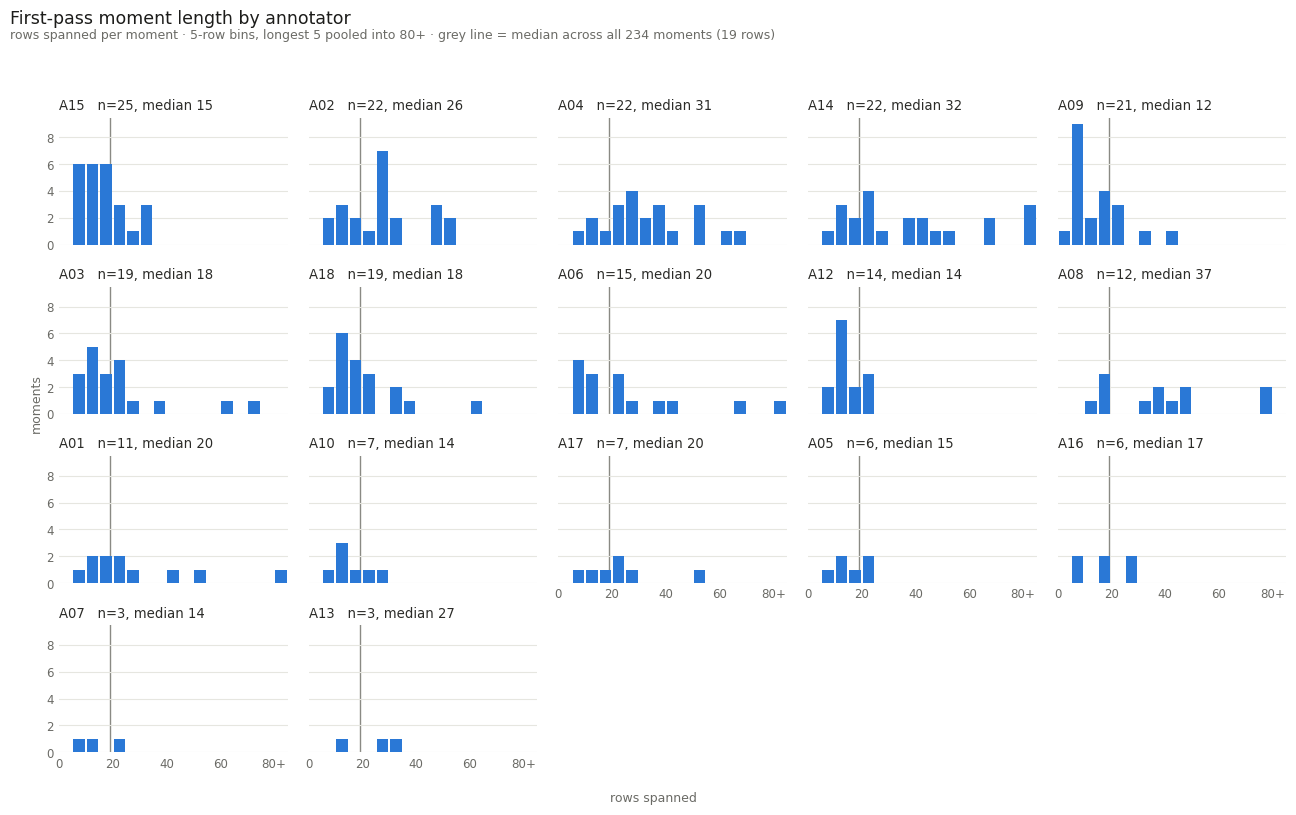

In [48]:
import matplotlib.pyplot as plt

FILL = "#2a78d6"      # one hue for every panel; the panel title carries identity, not colour
BIN_WIDTH = 5         # rows per bin
OVERFLOW = 80         # a handful of moments run far longer; they pool into a final "80+" bin
                      # rather than stretching every panel's axis out to the longest one

first_pass_lengths = {}
for m in moments:
    span = m["moment"]["end_turn"] - m["moment"]["start_turn"] + 1
    for a in m["annotations"]:
        if a["role"] == "selector":
            first_pass_lengths.setdefault(a["annotator_id"], []).append(span)

people = sorted(first_pass_lengths, key=lambda p: (-len(first_pass_lengths[p]), label(p)))
every_length = [n for lengths in first_pass_lengths.values() for n in lengths]
overall = median(every_length)
bins = range(0, OVERFLOW + 2 * BIN_WIDTH, BIN_WIDTH)
pooled = sum(1 for n in every_length if n >= OVERFLOW)

COLUMNS = 5
rows = -(-len(people) // COLUMNS)
fig, axes = plt.subplots(rows, COLUMNS, figsize=(13, 2.05 * rows), sharex=True, sharey=True)

for ax, person in zip(axes.flat, people):
    lengths = first_pass_lengths[person]
    ax.hist([min(n, OVERFLOW + BIN_WIDTH // 2) for n in lengths], bins=bins,
            color=FILL, rwidth=0.85)
    # A common reference line makes panels comparable at a glance despite differing n.
    ax.axvline(overall, color="#8a8a84", linewidth=1, zorder=0)
    ax.set_title(f"{label(person)}   n={len(lengths)}, median {median(lengths):.0f}",
                 fontsize=9.5, loc="left", color="#2b2b28")

for ax in axes.flat[len(people):]:
    ax.set_visible(False)

# sharex labels only the bottom row, so a column that runs out of panels early would lose its
# scale entirely; label the last panel actually drawn in each column.
for column in range(COLUMNS):
    drawn = list(range(column, len(people), COLUMNS))
    if drawn:
        axes.flat[drawn[-1]].tick_params(labelbottom=True)

for ax in axes.flat:
    ax.set_xticks([0, 20, 40, 60, 80])
    ax.set_xticklabels(["0", "20", "40", "60", f"{OVERFLOW}+"])
    ax.set_xlim(0, OVERFLOW + BIN_WIDTH)
    ax.tick_params(labelsize=8.5, colors="#6b6b66", length=0)
    ax.grid(axis="y", color="#e6e6e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ax.spines.values():
        side.set_visible(False)

fig.suptitle("First-pass moment length by annotator", x=0.005, ha="left",
             fontsize=12.5, color="#1c1c1a")
fig.text(0.005, 0.945, f"rows spanned per moment · {BIN_WIDTH}-row bins, longest {pooled} "
         f"pooled into {OVERFLOW}+ · grey line = median across all {len(every_length)} "
         f"moments ({overall:.0f} rows)", fontsize=9, color="#6b6b66")
fig.supxlabel("rows spanned", fontsize=9, color="#6b6b66")
fig.supylabel("moments", fontsize=9, color="#6b6b66")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## Situation

Whether the moment was an appropriate occasion for scaffolding and/or for rigor —
`payload.situation.{scaffolding,rigor}_appropriate`, two independent booleans.

Counts use first passes only (one selector annotation per moment, so n = the moment count).
Agreement uses the doubly annotated moments, selector vs. reannotator. A reannotation that threw
the moment out leaves `situation` empty and carries no judgment to compare, so those pairs drop
out of the kappa and are reported separately.


In [49]:
from sklearn.metrics import cohen_kappa_score

SITUATION_FIELDS = ("scaffolding_appropriate", "rigor_appropriate")


def pass_of(m, role):
    return next((a for a in m["annotations"] if a["role"] == role), None)


def situation(annotation):
    """The situation judgment, or None when the annotator recorded none (thrown-out moments)."""
    return (annotation["payload"].get("situation") or None) if annotation else None


first_pass = [situation(pass_of(m, "selector")) for m in moments]
scaffolding_appropriate = [s for s in first_pass if s["scaffolding_appropriate"]]
rigor_appropriate = [s for s in first_pass if s["rigor_appropriate"]]
both = [s for s in first_pass if s["scaffolding_appropriate"] and s["rigor_appropriate"]]
neither = [s for s in first_pass if not s["scaffolding_appropriate"] and not s["rigor_appropriate"]]

print(f"First annotations only (n={len(first_pass)})")
print(f"  # scaffolding-appropriate moments : {len(scaffolding_appropriate):>3} "
      f"({len(scaffolding_appropriate) / len(first_pass):.1%})")
print(f"  # rigor-appropriate moments       : {len(rigor_appropriate):>3} "
      f"({len(rigor_appropriate) / len(first_pass):.1%})")
print(f"      both                          : {len(both):>3}")
print(f"      neither                       : {len(neither):>3}")


First annotations only (n=234)
  # scaffolding-appropriate moments : 155 (66.2%)
  # rigor-appropriate moments       :  91 (38.9%)
      both                          :  12
      neither                       :   0


In [50]:
pairs, no_judgment = [], []
for m in doubly_annotated:
    first = situation(pass_of(m, "selector"))
    second = situation(pass_of(m, "reannotator"))
    if first and second:
        pairs.append((first, second))
    else:
        no_judgment.append(m)

print(f"Doubly annotated moments ({len(doubly_annotated)}), "
      f"{len(no_judgment)} without a second situation judgment (thrown out)\n")
print(f"Cohen's kappa (n={len(pairs)}) of situation appropriateness:")
for field in SITUATION_FIELDS:
    a = [first[field] for first, _ in pairs]
    b = [second[field] for _, second in pairs]
    agreed = sum(x == y for x, y in zip(a, b))
    print(f"  {field:<24} kappa = {cohen_kappa_score(a, b):.3f}   "
          f"raw agreement {agreed}/{len(pairs)} ({agreed / len(pairs):.1%})")

# The two flags are independent in principle, but check whether the raters actually treated them
# as one either/or call -- if so the two kappas above are measuring the same judgment twice.
complementary = sum(
    s["rigor_appropriate"] == (not s["scaffolding_appropriate"])
    for pair in pairs for s in pair
)
print(f"\n{complementary}/{2 * len(pairs)} judgments in this subset set exactly one flag "
      f"(rigor = not scaffolding)")


Doubly annotated moments (40), 3 without a second situation judgment (thrown out)

Cohen's kappa (n=37) of situation appropriateness:
  scaffolding_appropriate  kappa = 0.516   raw agreement 30/37 (81.1%)
  rigor_appropriate        kappa = 0.516   raw agreement 30/37 (81.1%)

74/74 judgments in this subset set exactly one flag (rigor = not scaffolding)


## Action

What the tutor actually did — `payload.action`. Scaffolding and rigor are recorded independently:
each has a `_present` flag, and when present, an amount. `scaffolding_amount == "over_scaffolding"`
unlocks `over_scaffolding_reasons`, a multi-select; rigor carries `rigor_amount` (weak/strong) and
a multi-select `rigor_strategies`.

Multi-select rows count moments, so those columns sum past the subset total — percentages are of
the moments in the subset, not of each other.


In [51]:
def action(annotation):
    """The action judgment, or None when the annotator recorded none (thrown-out moments)."""
    return (annotation["payload"].get("action") or None) if annotation else None


def breakdown(counts, denominator, indent=6):
    """Print a count/percent table, most common first. Percentages are of `denominator` moments."""
    for name, n in counts.most_common():
        print(f"{'':{indent}}{name:<34}{n:>4}  ({n / denominator:5.1%})")


first_action = [action(pass_of(m, "selector")) for m in moments]
scaffolding = [a for a in first_action if a["scaffolding_present"]]
rigor = [a for a in first_action if a["rigor_present"]]

print(f"First annotations only (n={len(first_action)})\n")
print(f"  # scaffolding present : {len(scaffolding):>3} ({len(scaffolding) / len(first_action):.1%})")
breakdown(Counter(a["scaffolding_amount"] for a in scaffolding), len(scaffolding))

over = [a for a in scaffolding if a["scaffolding_amount"] == "over_scaffolding"]
print(f"\n  over-scaffolding type (n={len(over)} moments, multi-select):")
breakdown(Counter(r for a in over for r in a.get("over_scaffolding_reasons", [])), len(over))

print(f"\n  # push for rigor present : {len(rigor):>3} ({len(rigor) / len(first_action):.1%})")
print(f"\n  rigor amount (n={len(rigor)}):")
breakdown(Counter(a["rigor_amount"] for a in rigor), len(rigor))
print(f"\n  rigor strategy (n={len(rigor)} moments, multi-select):")
breakdown(Counter(s for a in rigor for s in a.get("rigor_strategies", [])), len(rigor))
blank = sum(1 for a in rigor if not a.get("rigor_strategies"))
if blank:
    print(f"{'':6}({blank} rigor moments list no strategy)")


First annotations only (n=234)

  # scaffolding present : 174 (74.4%)
      over_scaffolding                    76  (43.7%)
      appropriate                         74  (42.5%)
      under_scaffolding                   15  ( 8.6%)
      unclear                              9  ( 5.2%)

  over-scaffolding type (n=76 moments, multi-select):
      most_cognitive_work                 43  (56.6%)
      premature_scaffolding               33  (43.4%)
      gives_away_answers                  31  (40.8%)
      no_opening_demonstrate              28  (36.8%)
      procedural_insufficient_reasoning   21  (27.6%)
      over_explains                       18  (23.7%)
      fails_to_fade                       17  (22.4%)
      no_opening_contribute               15  (19.7%)
      re_scaffolds                         8  (10.5%)
      oversimplifies                       7  ( 9.2%)
      jumps_in_struggle                    5  ( 6.6%)

  # push for rigor present :  39 (16.7%)

  rigor amount (n=39):

In [52]:
def agreement(pairs, key, caption):
    """Cohen's kappa, with the raw agreement and marginals it is computed from.

    Kappa alone misleads on a skewed flag -- raters can agree most of the time and still score near
    zero -- so how often each rater set the flag is printed alongside it.
    """
    a = [key(first) for first, _ in pairs]
    b = [key(second) for _, second in pairs]
    agreed = sum(x == y for x, y in zip(a, b))
    marginals = f"flagged {sum(a):>2} / {sum(b):>2}" if all(isinstance(x, bool) for x in a) else ""
    print(f"  {caption:<28} kappa = {cohen_kappa_score(a, b):>6.3f}   "
          f"raw agreement {agreed}/{len(pairs)} ({agreed / len(pairs):5.1%})   {marginals}")


action_pairs, no_action = [], []
for m in doubly_annotated:
    first, second = action(pass_of(m, "selector")), action(pass_of(m, "reannotator"))
    if first and second:
        action_pairs.append((first, second))
    else:
        no_action.append(m)

print(f"Doubly annotated moments ({len(doubly_annotated)}), "
      f"{len(no_action)} without a second action judgment (thrown out)\n")
print(f"Action direction agreement (n={len(action_pairs)}), per flag:")
agreement(action_pairs, lambda a: a["scaffolding_present"], "scaffolding present")
agreement(action_pairs, lambda a: a["rigor_present"], "rigor present")

# scaffolding_amount is only filled in when that rater saw scaffolding, so over-scaffolding
# agreement is conditioned on both raters having recorded an amount at all.
amount_pairs = [(f, s) for f, s in action_pairs if f["scaffolding_amount"] and s["scaffolding_amount"]]
print(f"\nOver-scaffolding agreement (n={len(amount_pairs)} pairs where both saw scaffolding):")
agreement(amount_pairs, lambda a: a["scaffolding_amount"] == "over_scaffolding", "over-scaffolding (yes/no)")
agreement(amount_pairs, lambda a: a["scaffolding_amount"], "scaffolding amount (4-way)")


Doubly annotated moments (40), 3 without a second action judgment (thrown out)

Action direction agreement (n=37), per flag:
  scaffolding present          kappa =  0.216   raw agreement 27/37 (73.0%)   flagged 31 / 27
  rigor present                kappa = -0.088   raw agreement 29/37 (78.4%)   flagged  2 /  6

Over-scaffolding agreement (n=24 pairs where both saw scaffolding):
  over-scaffolding (yes/no)    kappa =  0.149   raw agreement 14/24 (58.3%)   flagged  9 / 11
  scaffolding amount (4-way)   kappa =  0.215   raw agreement 12/24 (50.0%)   


## Result

What happened to the student — `payload.result`, two single-select scales recorded independently:
`problem_success` (meaningful_success / not_meaningful / no_success / not_enough_evidence) and
`cognitive_engagement` (high_or_good / low / not_enough_evidence). Every included first pass fills
both.

Counts use first passes only, as above; agreement uses the doubly annotated moments, selector vs.
reannotator, with thrown-out reannotations reported separately. Kappa is reported three ways — on
the scales as recorded, collapsed to the headline call, and with the `not_enough_evidence` pairs
dropped — because a multi-level scale can score low from raters landing on adjacent levels rather
than from real disagreement about the student.


In [53]:
RESULT_FIELDS = ("problem_success", "cognitive_engagement")
SUCCESS_ORDER = ("meaningful_success", "not_meaningful", "no_success", "not_enough_evidence")
ENGAGEMENT_ORDER = ("high_or_good", "low", "not_enough_evidence")


def result(annotation):
    """The result judgment, or None when the annotator recorded none (thrown-out moments)."""
    return (annotation["payload"].get("result") or None) if annotation else None


first_result = [result(pass_of(m, "selector")) for m in moments]

print(f"First annotations only (n={len(first_result)})\n")
for field in RESULT_FIELDS:
    print(f"  {field.replace('_', ' ')}:")
    breakdown(Counter(r[field] for r in first_result), len(first_result))
    print()

# The two are separate calls -- solving the problem and thinking hard about it come apart -- so
# cross-tabulate rather than reporting only the margins.
joint = Counter((r["problem_success"], r["cognitive_engagement"]) for r in first_result)
print("  problem success x cognitive engagement:")
print(f"{'':6}{'':<22}" + "".join(f"{e:>21}" for e in ENGAGEMENT_ORDER))
for success in SUCCESS_ORDER:
    row = "".join(f"{joint[(success, e)]:>21}" for e in ENGAGEMENT_ORDER)
    print(f"{'':6}{success:<22}{row}")


First annotations only (n=234)

  problem success:
      not_meaningful                      97  (41.5%)
      meaningful_success                  71  (30.3%)
      no_success                          47  (20.1%)
      not_enough_evidence                 19  ( 8.1%)

  cognitive engagement:
      low                                142  (60.7%)
      high_or_good                        82  (35.0%)
      not_enough_evidence                 10  ( 4.3%)

  problem success x cognitive engagement:
                                     high_or_good                  low  not_enough_evidence
      meaningful_success                       59                   12                    0
      not_meaningful                           16                   80                    1
      no_success                                4                   39                    4
      not_enough_evidence                       3                   11                    5


In [54]:
result_pairs, no_result = [], []
for m in doubly_annotated:
    first, second = result(pass_of(m, "selector")), result(pass_of(m, "reannotator"))
    if first and second:
        result_pairs.append((first, second))
    else:
        no_result.append(m)

print(f"Doubly annotated moments ({len(doubly_annotated)}), "
      f"{len(no_result)} without a second result judgment (thrown out)\n")
print(f"Result agreement (n={len(result_pairs)}), on the scales as recorded:")
agreement(result_pairs, lambda r: r["problem_success"], "problem success (4-way)")
agreement(result_pairs, lambda r: r["cognitive_engagement"], "cognitive engagement (3-way)")

# Both scales fold to one substantive call, so a low kappa above may be raters splitting hairs
# over neighbouring levels rather than actually disagreeing about the student.
print(f"\nCollapsed to the headline call (n={len(result_pairs)}):")
agreement(result_pairs, lambda r: r["problem_success"] == "meaningful_success", "meaningful success (yes/no)")
agreement(result_pairs, lambda r: r["cognitive_engagement"] == "high_or_good", "high engagement (yes/no)")

# "not_enough_evidence" is a statement about the moment, not about the student, so one rater
# picking it is a different kind of disagreement -- check the kappas without those pairs.
evidence_pairs = [
    (f, s) for f, s in result_pairs
    if "not_enough_evidence" not in (f["problem_success"], s["problem_success"],
                                     f["cognitive_engagement"], s["cognitive_engagement"])
]
print(f"\nPairs where both raters saw enough evidence on both scales (n={len(evidence_pairs)}):")
agreement(evidence_pairs, lambda r: r["problem_success"], "problem success (3-way)")
agreement(evidence_pairs, lambda r: r["cognitive_engagement"], "cognitive engagement (2-way)")


Doubly annotated moments (40), 3 without a second result judgment (thrown out)

Result agreement (n=37), on the scales as recorded:
  problem success (4-way)      kappa =  0.181   raw agreement 17/37 (45.9%)   
  cognitive engagement (3-way) kappa =  0.297   raw agreement 22/37 (59.5%)   

Collapsed to the headline call (n=37):
  meaningful success (yes/no)  kappa =  0.260   raw agreement 25/37 (67.6%)   flagged 12 / 12
  high engagement (yes/no)     kappa =  0.329   raw agreement 25/37 (67.6%)   flagged 11 / 17

Pairs where both raters saw enough evidence on both scales (n=31):
  problem success (3-way)      kappa =  0.187   raw agreement 15/31 (48.4%)   
  cognitive engagement (2-way) kappa =  0.297   raw agreement 20/31 (64.5%)   
